In [1]:
# ============================================================================
# TFG — Optimización de turbinas hidroeléctricas en el río Sil
# Benchmark: NSGA-II vs SPEA2 vs MOEA/D + Análisis de Sensibilidad
# Autor: Yoel Urquijo Barroso | GIF-25025 | UAX
# ============================================================================

!pip install pymoo > /dev/null 2>&1

import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy.stats import wilcoxon
from itertools import combinations
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.algorithms.moo.spea2 import SPEA2
from pymoo.algorithms.moo.moead import MOEAD
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.repair.rounding import RoundingRepair
from pymoo.optimize import minimize
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.indicators.hv import HV
from pymoo.termination import get_termination

In [2]:
# Reproducibilidad y accesibilidad

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Rutas a los csv
RUTA_COSTES  = '/content/drive/MyDrive/TFG - UAX/CSV/parametros_costes.csv'
RUTA_FISICOS = '/content/drive/MyDrive/TFG - UAX/CSV/parametros_fisicos.csv'
RUTA_RIO     = '/content/drive/MyDrive/TFG - UAX/CSV/Sil_Dataset_Completo.csv'

# Cargamos los diccionarios y los unimos
try:
    dict_costes  = pd.read_csv(RUTA_COSTES).iloc[0].to_dict()
    dict_fisicos = pd.read_csv(RUTA_FISICOS).iloc[0].to_dict()

    # Unimos ambos diccionarios
    PARAMS = {**dict_costes, **dict_fisicos}

    # Calculamos la obra civil lineal (60% del coste total de obra civil)
    PARAMS['eur_metro'] = PARAMS['eur_kw_obra_civil'] * 0.60
    PARAMS['pot_max_kw'] = 10_000
    PARAMS['pot_max_kw_ref'] = 'RD 413/2014. Art.2. Potencia máxima minicentral.'

    print('Configuracion cargada correctamente:')
    print(f"->Rendimiento (eta):        {PARAMS['eta']} -> {str(PARAMS['eta_ref'])[:40]}...")
    print(f"-> Precio Venta Energía:     {PARAMS['precio_kwh']} €/kWh")
    print(f"-> Inversión Actualizada:    {PARAMS['ratio_eur_kw_actualizado']:.0f} €/kW (Factor IPC: ×{PARAMS['factor_ipc']})")
    print(f"-> Mantenimiento Anual:      {PARAMS['mant_eur_kw_anio']:.2f} €/kW·año")

except FileNotFoundError as e:
    print(f"Error: Faltan archivos csv. Revisa tus rutas. Error: {e}")

Configuracion cargada correctamente:
->Rendimiento (eta):        0.85 -> Paish (2002). Small hydro power. Renewab...
-> Precio Venta Energía:     0.08 €/kWh
-> Inversión Actualizada:    2258 €/kW (Factor IPC: ×1.505)
-> Mantenimiento Anual:      67.72 €/kW·año


In [3]:
# Carga de datos
df_rio = pd.read_csv(RUTA_RIO).reset_index(drop=True)
TOTAL_PUNTOS = len(df_rio)

# Constantes físicas del río
Q_MAX = df_rio['Q_medio'].max()
H_MAX = df_rio['Elevacion_m'].max() - df_rio['Elevacion_m'].min()
POT_MAX_FISICA = 9.81 * Q_MAX * H_MAX * PARAMS['eta']

ELEVACION = df_rio['Elevacion_m'].values
DISTANCIA = df_rio['Distancia_m'].values
ANGULO    = df_rio['Angulo'].values
CAUDAL    = df_rio['Q_medio'].values

CAU_INV = df_rio['Caudal_Invierno'].values
CAU_PRI = df_rio['Caudal_Primavera'].values
CAU_VER = df_rio['Caudal_Verano'].values
CAU_OTO = df_rio['Caudal_Otono'].values

print(f"Dataset cargado: {TOTAL_PUNTOS} puntos")
print(f"Potencia Teórica Máxima del Sil: {POT_MAX_FISICA/1000:.1f} MW")

Dataset cargado: 2005 puntos
Potencia Teórica Máxima del Sil: 90.0 MW


In [4]:
# Definicion del problema y validacion
def validar_solucion(row):
    """Valida físicamente una solución del frente de Pareto.
    Filtra soluciones inválidas en lugar de crashear."""
    if row['salto_m'] <= 0:
        return False
    if row['caudal_m3s'] <= 0:
        return False
    if row['potencia_kw'] > PARAMS.get('pot_max_kw', 10_000) * 1.001:
        return False
    return True

class ProblemaHidro(Problem):
    def __init__(self, p=PARAMS):
        super().__init__(
            n_var=2, n_obj=2, xl=np.array([0, 1]),
            xu=np.array([TOTAL_PUNTOS - 2, TOTAL_PUNTOS - 1]), vtype=int
        )
        self.p = p

    def _evaluate(self, X, out, *args, **kwargs):
        idx_toma = X[:, 0].astype(int)
        idx_turb = X[:, 1].astype(int)

        # Acceso vectorizado
        salto     = ELEVACION[idx_toma] - ELEVACION[idx_turb]
        distancia = DISTANCIA[idx_turb] - DISTANCIA[idx_toma]
        ang_diff  = np.abs(ANGULO[idx_turb] - ANGULO[idx_toma])

        # Calculo estacional — Potencia por estación (kW)
        pot_inv = np.where(salto > 0, 9.81 * CAU_INV[idx_toma] * salto * self.p['eta'], 0.0)
        pot_pri = np.where(salto > 0, 9.81 * CAU_PRI[idx_toma] * salto * self.p['eta'], 0.0)
        pot_ver = np.where(salto > 0, 9.81 * CAU_VER[idx_toma] * salto * self.p['eta'], 0.0)
        pot_oto = np.where(salto > 0, 9.81 * CAU_OTO[idx_toma] * salto * self.p['eta'], 0.0)

        # Energía anual ponderada (kWh)
        energia_anual = (pot_inv * 90 * 24) + (pot_pri * 91 * 24) + (pot_ver * 92 * 24) + (pot_oto * 92 * 24)

        # Potencia instalada (diseño para caudal pico: invierno o primavera)
        potencia_diseno = np.maximum(pot_inv, pot_pri)

        # Restricciones físicas + legal (Máximo 10 MW = 10.000 kW — RD 413/2014)
        valido = (
            (idx_toma < idx_turb) &
            (salto > 0) &
            (distancia >= self.p['dist_min_m']) &
            (potencia_diseno <= self.p.get('pot_max_kw', 10_000))
        )
        pen = np.where(
            valido, 0.0,
            np.abs(salto) +
            np.clip(self.p['dist_min_m'] - distancia, 0, None) +
            np.clip(potencia_diseno - self.p.get('pot_max_kw', 10_000), 0, None)
        )

        # Costes
        coste_equipo     = np.where(valido, potencia_diseno * (self.p['eur_kw_turbogenerador'] + self.p['eur_kw_electrico']), 0.0)
        coste_civil      = np.where(valido, distancia * self.p['eur_metro'] + ang_diff * self.p['eur_grado'], 0.0)
        coste_base       = coste_equipo + coste_civil + self.p['coste_conexion']
        coste_ingenieria = coste_base * self.p['pct_ingenieria']
        mant_total       = np.where(valido, potencia_diseno * self.p['mant_eur_kw_anio'] * self.p['vida_util_anios'], 0.0)
        coste_total_vida = coste_base + coste_ingenieria + mant_total

        # Objetivos
        f1 = np.where(valido, -energia_anual,    1e10 + pen * 1e6)
        f2 = np.where(valido,  coste_total_vida, 1e12 + pen * 1e6)

        out["F"] = np.column_stack([f1, f2])


def frente_a_dataframe(res, nombre_algoritmo, p=PARAMS):
    filas = []
    for i in range(len(res.X)):
        idx_toma, idx_turb = int(res.X[i, 0]), int(res.X[i, 1])
        energia          = -res.F[i, 0]   # kWh/año ponderado estacional
        coste_total_vida =  res.F[i, 1]

        salto         = ELEVACION[idx_toma] - ELEVACION[idx_turb]
        caudal_diseno = max(float(CAU_INV[idx_toma]), float(CAU_PRI[idx_toma]))
        potencia      = 9.81 * caudal_diseno * salto * p['eta']
        caudal_medio  = CAUDAL[idx_toma]
        opex_anual    = potencia * p['mant_eur_kw_anio']
        capex         = coste_total_vida - (opex_anual * p['vida_util_anios'])
        ingreso_bruto = energia * p['precio_kwh']
        flujo_neto    = ingreso_bruto - opex_anual
        payback       = capex / flujo_neto if flujo_neto > 0 else 99.0

        filas.append({
            'Algoritmo':          nombre_algoritmo,
            'idx_toma':           idx_toma,
            'idx_turbina':        idx_turb,
            'distancia_toma_m':   DISTANCIA[idx_toma],
            'distancia_turb_m':   DISTANCIA[idx_turb],
            'elevacion_toma_m':   ELEVACION[idx_toma],
            'elevacion_turb_m':   ELEVACION[idx_turb],
            'salto_m':            salto,
            'caudal_m3s':         caudal_medio,
            'potencia_kw':        potencia,
            'energia_kwh':        energia,
            'capex_inversion_eur': capex,
            'opex_anual_eur':     opex_anual,
            'ingreso_bruto_eur':  ingreso_bruto,
            'flujo_neto_eur':     flujo_neto,
            'payback_anios':      payback,
        })
    return pd.DataFrame(filas).sort_values('energia_kwh', ascending=False)

In [5]:
# Operadores y benchmark
def get_operadores():
    return dict(
        sampling  = IntegerRandomSampling(),
        crossover = SBX(prob=0.9, eta=15, vtype=float, repair=RoundingRepair()),
        mutation  = PM(prob=0.2, eta=20, vtype=float, repair=RoundingRepair())
    )

def ejecutar_benchmark_multi(n_pop=200, n_gen=100, n_runs=10, p=PARAMS):
    problema = ProblemaHidro(p)
    termination = get_termination("n_gen", n_gen)
    seeds = [SEED + i*7 for i in range(n_runs)]

    def make_nsga2(): return NSGA2(pop_size=n_pop, **get_operadores())
    def make_spea2(): return SPEA2(pop_size=n_pop, **get_operadores())
    def make_moead():
        ref_dirs = get_reference_directions("uniform", 2, n_points=n_pop)
        return MOEAD(ref_dirs=ref_dirs, n_neighbors=15, prob_neighbor_mating=0.7, **get_operadores())

    fabricas = {"NSGA-II": make_nsga2, "SPEA2": make_spea2, "MOEA/D": make_moead}
    resultados_multi = {n: [] for n in fabricas}

    print(f"\n{'='*60}\n  BENCHMARK MULTI-RUN — NSGA-II vs SPEA2 vs MOEA/D\n{'='*60}")

    tiempos = {}

    for nombre, fab in fabricas.items():
        print(f"{nombre} — {n_runs} runs:")
        t0 = time.time()
        for k, seed_val in enumerate(seeds):
            alg = fab()
            res = minimize(problema, alg, termination, seed=seed_val, save_history=True, verbose=False)
            resultados_multi[nombre].append(res)
            print(f"run {k+1:2d}/{n_runs}  seed={seed_val:3d}  frente={len(res.F)} soluciones")

        elapsed = round(time.time() - t0, 1)
        tiempos[nombre] = elapsed
        print(f"Completado en {elapsed:.1f}s\n")

    todos_F = np.vstack([res.F for runs in resultados_multi.values() for res in runs])
    ref_point = np.array([todos_F[:, 0].max() * 1.1, todos_F[:, 1].max() * 1.1])

    hv_calc = HV(ref_point=ref_point)
    resultados_mejor = {}
    for nombre, runs in resultados_multi.items():
        hvs = [
                 hv_calc(r.F[r.F[:, 1] < 1e10]) if len(r.F[r.F[:, 1] < 1e10]) > 0 else 0
                for r in runs
              ]
        resultados_mejor[nombre] = runs[int(np.argmax(hvs))]

    return resultados_multi, resultados_mejor, ref_point, tiempos

In [6]:
# Metricas(HV Y Spacing) y estadísticas
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon
from itertools import combinations
from pymoo.indicators.hv import HV

def calc_spacing(F):
    if len(F) < 2: return 0.0
    F_norm = (F - F.min(axis=0)) / (F.max(axis=0) - F.min(axis=0) + 1e-9)
    distancias = []
    for i in range(len(F_norm)):
        diffs = np.linalg.norm(F_norm - F_norm[i], ord=1, axis=1)
        diffs[i] = np.inf
        distancias.append(np.min(diffs))
    d_mean = np.mean(distancias)
    distancias = np.array(distancias)
    return np.sqrt(np.sum((distancias - d_mean)**2) / (len(F_norm) - 1))

def calcular_metricas_extendidas(resultados_multi, ref_point, tiempos=None):
    hv_calc = HV(ref_point=ref_point)
    metricas = {}
    hv_runs = {n: [] for n in resultados_multi}
    sp_runs = {n: [] for n in resultados_multi}

    # Cálculos
    for nombre, runs in resultados_multi.items():
        for res in runs:
            F_valido = res.F[res.F[:, 1] < 1e10]
            if len(F_valido) > 0:
                hv_runs[nombre].append(hv_calc(F_valido))
                sp_runs[nombre].append(calc_spacing(F_valido))
            else:
                hv_runs[nombre].append(0)
                sp_runs[nombre].append(np.inf)

        metricas[nombre] = {
            'hv_mean':   np.mean(hv_runs[nombre]),
            'hv_median': np.median(hv_runs[nombre]),
            'hv_std':    np.std(hv_runs[nombre], ddof=1),
            'hv_min':    np.min(hv_runs[nombre]),
            'hv_max':    np.max(hv_runs[nombre]),
            'sp_mean':   np.mean(sp_runs[nombre]),
            'sp_median': np.median(sp_runs[nombre]),
            'sp_std':    np.std(sp_runs[nombre], ddof=1),
        }

    # Resumen estadístico completo
    sep = '=' * 72
    print(f"\n{sep}")
    print(f"  ESTADÍSTICAS EXTENDIDAS — HV y SPACING (10 runs, semillas fijas)")
    print(f"{sep}")

    # Cabecera
    print(f"\n  {'Algoritmo':<10} {'HV Mediana':>14} {'HV Media':>14} {'HV Std':>12} "
          f"{'HV Min':>12} {'HV Max':>12}")
    print(f"  {'-'*66}")
    for nombre, m in metricas.items():
        print(f"  {nombre:<10} {m['hv_median']:>14.4e} {m['hv_mean']:>14.4e} "
              f"{m['hv_std']:>12.2e} {m['hv_min']:>12.4e} {m['hv_max']:>12.4e}")

    print(f"\n  {'Algoritmo':<10} {'Spacing Med':>14} {'Spacing µ':>14} {'Spacing σ':>12}  "
          f"{'Interpretación':>20}")
    print(f"  {'-'*66}")
    for nombre, m in metricas.items():
        interp = "✓ Muy uniforme" if m['sp_median'] < 0.003 else \
                 "~ Aceptable"    if m['sp_median'] < 0.006 else \
                 "✗ Irregular"
        print(f"  {nombre:<10} {m['sp_median']:>14.4f} {m['sp_mean']:>14.4f} "
              f"{m['sp_std']:>12.4f}  {interp:>20}")

    # Ranking automático por HV mediano
    ranking = sorted(metricas.items(), key=lambda x: x[1]['hv_median'], reverse=True)
    print(f"\n  Ranking HV (mayor = mejor frente de Pareto):")
    for pos, (nombre, m) in enumerate(ranking, 1):
        mejora = ""
        if pos > 1:
            ref_hv = ranking[0][1]['hv_median']
            pct = (ref_hv - m['hv_median']) / ref_hv * 100
            mejora = f"  ({pct:.1f}% inferior al líder)"
        print(f"    #{pos} {nombre:<10} HV={m['hv_median']:.4e}{mejora}")

    # Wilcoxon + Holm-Bonferroni
    print(f"\n{'-'*72}")
    print(f"  Test Wilcoxon + correción Holm-Bonferroni (HV => Mayor es mejor)")
    print(f"  α = 0.05 | Comparaciones múltiples: {len(list(combinations(resultados_multi.keys(), 2)))} pares")
    print(f"{'-'*72}")

    nombres = list(resultados_multi.keys())
    pares = list(combinations(nombres, 2))
    p_values = []

    for n1, n2 in pares:
        d1, d2 = np.array(hv_runs[n1]), np.array(hv_runs[n2])
        if np.all(d1 == d2):
            p = 1.0
        else:
            _, p = wilcoxon(d1, d2, zero_method='zsplit')
        p_values.append((n1, n2, p))

    p_values.sort(key=lambda x: x[2])
    m_pares = len(pares)

    filas_wilcoxon = []
    for i, (n1, n2, p) in enumerate(p_values):
        umbral_holm = 0.05 / (m_pares - i)
        significativo = "Sí es significativo" if p < umbral_holm else "No es significativo"
        conclusion = "Diferencia significativa" if p < umbral_holm else "Sin diferencia significativa"
        filas_wilcoxon.append({
            'Comparativa':  f"{n1} vs {n2}",
            'p-valor':      f"{p:.4e}",
            'Umbral Holm':  f"{umbral_holm:.4e}",
            'Sig.':         significativo,
            'Conclusión':   conclusion
        })

    df_wilcoxon = pd.DataFrame(filas_wilcoxon)
    print(df_wilcoxon.to_string(index=False))

    # Tabla tiempos
    if tiempos:
        print(f"\n{'-'*85}")
        print(f"  TABLA RESUMEN EJECUTIVA (Desempate por eficiencia computacional y estabilidad)")
        print(f"{'-'*85}")
        print(f"  {'Algoritmo':<10} {'HV Mediana':>14} {'HV Std':>12} {'Spacing Med':>12} {'Tiempo':>10} {'Veredicto':>22}")
        print(f"  {'-'*85}")

        max_hv_mediana = max(v['hv_median'] for v in metricas.values())
        min_hv_std = min(v['hv_std'] for v in metricas.values())

        for nombre, m in metricas.items():
            t = f"{tiempos[nombre]:.1f}s"
            if m['hv_median'] == max_hv_mediana:
                if m['hv_std'] == min_hv_std:
                    veredicto = "★ Mejor (HV+estab.)"
                else:
                    veredicto = "★ Mejor HV"
            elif m['hv_median'] < (max_hv_mediana * 0.98):
                veredicto = "✗ Inferior"
            else:
                veredicto = "≈ Equivalente"

            print(f"  {nombre:<10} {m['hv_median']:>14.4e} {m['hv_std']:>12.2e} {m['sp_median']:>12.4f} {t:>10} {veredicto:>22}")

    print(f"{sep}\n")

    return metricas, hv_runs, sp_runs

In [7]:
# Visualizaciones y gráficas
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import numpy as np

COLORES = {"NSGA-II": "#1D9E75", "SPEA2": "#7F77DD", "MOEA/D": "#D85A30"}

def graficar_estadisticas(hv_runs, metricas):
    nombres = list(hv_runs.keys())
    datos   = [hv_runs[n] for n in nombres]
    colores = [COLORES[n] for n in nombres]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'Análisis estadístico del Hypervolume (10 runs)\nYoel Urquijo Barroso | GIF-25025 | UAX', fontsize=12, fontweight='bold')

    ax = axes[0]
    parts = ax.violinplot(datos, positions=range(len(nombres)), showmedians=True, showextrema=True)
    for pc, col in zip(parts['bodies'], colores):
        pc.set_facecolor(col)
        pc.set_alpha(0.45)
    parts['cmedians'].set_color('black')
    for i, (d, col) in enumerate(zip(datos, colores)):
        jitter = np.random.RandomState(0).uniform(-0.07, 0.07, len(d))
        ax.scatter(i + jitter, d, color=col, s=40, zorder=5, edgecolors='white', linewidths=0.5, alpha=0.85)
    ax.set_xticks(range(len(nombres)))
    ax.set_xticklabels(nombres, fontsize=11)
    ax.set_ylabel('Hypervolume', fontsize=11)
    ax.set_title('Violín + puntos individuales', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    ax2 = axes[1]
    bp  = ax2.boxplot(datos, patch_artist=True, medianprops=dict(color='black', linewidth=2))
    for patch, col in zip(bp['boxes'], colores):
        patch.set_facecolor(col)
        patch.set_alpha(0.5)
    for i, (d, col) in enumerate(zip(datos, colores), 1):
        ax2.scatter(i, np.mean(d), marker='D', color=col, s=60, zorder=5, edgecolors='black', linewidths=0.8)
    for i, n in enumerate(nombres, 1):
        ax2.text(i, ax2.get_ylim()[1], f"{metricas[n]['hv_mean']:.3e}\n±{metricas[n]['hv_std']:.1e}",
                 ha='center', va='top', fontsize=8, color=colores[i-1], fontweight='bold')
    ax2.set_xticks(range(1, len(nombres)+1))
    ax2.set_xticklabels(nombres, fontsize=11)
    ax2.set_ylabel('Hypervolume', fontsize=11)
    ax2.set_title('Boxplot (◆ = media, línea = mediana)', fontsize=11, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('TFG_Stats_HV.png', dpi=150, bbox_inches='tight')
    plt.show()

def graficar_benchmark(resultados, metricas):
    fig = plt.figure(figsize=(20, 16))
    fig.suptitle('TFG — Optimización de turbinas hidroeléctricas en el río Sil\nBenchmark | Yoel Urquijo Barroso | UAX', fontsize=13, fontweight='bold', y=0.99)
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

    ax1 = fig.add_subplot(gs[0, :2])
    for nombre, res in resultados.items():
        ax1.scatter(-res.F[:, 0] / 1e6, res.F[:, 1] / 1e6, color=COLORES[nombre], s=50, alpha=0.7,
                    label=f"{nombre} (HV Mediano={metricas[nombre]['hv_median']:.2e})", edgecolors='white', linewidths=0.3)
    ax1.set_xlabel('Energía anual (GWh/año)', fontsize=11)
    ax1.set_ylabel('Coste de instalación (M€)', fontsize=11)
    ax1.set_title('Frentes de Pareto (Run representativa)', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2 = fig.add_subplot(gs[0, 2])
    nombres = list(metricas.keys())
    hvs     = [metricas[n]['hv_median'] for n in nombres]
    bars    = ax2.bar(nombres, hvs, color=[COLORES[n] for n in nombres], edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, hvs):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01, f'{val:.2e}', ha='center', va='bottom', fontsize=9)
    ax2.set_ylabel('Hypervolume', fontsize=11)
    ax2.set_title('Calidad del frente (HV Mediano)', fontsize=11, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')

    for j, (nombre, res) in enumerate(resultados.items()):
        ax  = fig.add_subplot(gs[1, j])
        col = COLORES[nombre]
        hist_max = []
        for gen_data in res.history:
            F_gen = gen_data.opt.get("F")
            if F_gen is not None and len(F_gen) > 0:
              F_valido = F_gen[F_gen[:, 0] < 0]
              if len(F_valido) > 0:
                hist_max.append(-F_valido[:, 0].min() / 1e6)
              else:
                hist_max.append(hist_max[-1] if hist_max else 0)
            else:
                hist_max.append(hist_max[-1] if hist_max else 0)

        gens = list(range(len(hist_max)))
        ax.plot(gens, hist_max, color=col, linewidth=2)
        ax.fill_between(gens, hist_max, alpha=0.15, color=col)
        ax.set_xlabel('Generación', fontsize=10)
        ax.set_ylabel('Mejor energía (GWh/año)', fontsize=10)
        ax.set_title(f'Convergencia — {nombre}', fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)

    plt.savefig('TFG_Benchmark_Resultados.png', dpi=150, bbox_inches='tight')
    plt.show()


def graficar_mapa_top(resultados):
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
    fig.suptitle('Top 3 ubicaciones por algoritmo — Perfil topográfico del Sil', fontsize=13, fontweight='bold')

    for ax, (nombre, res) in zip(axes, resultados.items()):
        col  = COLORES[nombre]
        df_p = frente_a_dataframe(res, nombre).head(3)
        ax.plot(df_rio['Distancia_m']/1000, df_rio['Elevacion_m'], color='#8B7355', linewidth=1.5, zorder=2)
        ax.fill_between(df_rio['Distancia_m']/1000, df_rio['Elevacion_m'], df_rio['Elevacion_m'].min() - 5, alpha=0.12, color='#8B7355')
        posiciones_x_ocupadas = []
        for rank, (_, row) in enumerate(df_p.iterrows(), 1):
            x_toma = row['distancia_toma_m'] / 1000
            y_toma = row['elevacion_toma_m']

            # Ajustar la altura de la etiqueta si hay puntos muy juntos
            offset_y = 15
            for x_previa in posiciones_x_ocupadas:
                if abs(x_toma - x_previa) < 0.8: # Si hay otra toma a menos de 800m
                    offset_y += 20 # Subimos la etiqueta un poco más

            posiciones_x_ocupadas.append(x_toma)

            ax.annotate('', xy=(row['distancia_turb_m']/1000, row['elevacion_turb_m']),
                        xytext=(x_toma, y_toma),
                        arrowprops=dict(arrowstyle='->', color=col, lw=2, alpha=0.8))

            ax.scatter(x_toma, y_toma, color='#1D9E75', s=80, zorder=5)
            ax.scatter(row['distancia_turb_m']/1000, row['elevacion_turb_m'], color=col, s=80, zorder=5, marker='v')

            # Caja de texto para que se lea siempre perfecto
            ax.text(x_toma, y_toma + offset_y,
                    f"#{rank} {row['potencia_kw']/1000:.1f}MW", fontsize=8, ha='center',
                    color='#333', fontweight='bold',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

        ax.legend(handles=[Line2D([0],[0], marker='o', color='w', markerfacecolor='#1D9E75', markersize=8, label='Toma'),
                           Line2D([0],[0], marker='v', color='w', markerfacecolor=col, markersize=8, label='Turbina')], fontsize=9)
        ax.set_xlabel('Distancia en el Sil (km)', fontsize=10)
        ax.set_ylabel('Elevación (m)', fontsize=10)
        ax.set_title(nombre, fontsize=12, fontweight='bold', color=col)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('TFG_Mapa_Ubicaciones.png', dpi=150, bbox_inches='tight')
    plt.show()

In [8]:
# Análisis de sensibilidad
def ejecutar_analisis_sensibilidad(modelo_ganador="NSGA-II"):
    print(f"\n{'='*60}")
    print(f"Ejecutando analisis de sensibilidad (Modelo: {modelo_ganador})")
    print(f"{'='*60}")

    escenarios = {
        "Base (Actual)": PARAMS.copy(),
        "Eta Bajo (-10%)": {**PARAMS, 'eta': PARAMS['eta'] * 0.90},
        "Eta Alto (+10%)": {**PARAMS, 'eta': min(1.0, PARAMS['eta'] * 1.10)},
        "Turbina Cara (+25%)": {**PARAMS, 'eur_kw_turbogenerador': PARAMS['eur_kw_turbogenerador'] * 1.25},
        "Obra Civil Barata (-50%)": {**PARAMS, 'eur_metro': PARAMS['eur_metro'] * 0.50},
        "Conexión ×2": {**PARAMS, 'coste_conexion': PARAMS['coste_conexion'] * 2.0}
    }

    resultados_sens = {}
    terminacion = get_termination("n_gen", 50)

    for nombre, p_es in escenarios.items():
        prob = ProblemaHidro(p_es)

        if modelo_ganador == "NSGA-II":
            alg = NSGA2(pop_size=100, **get_operadores())
        elif modelo_ganador == "SPEA2":
            alg = SPEA2(pop_size=100, **get_operadores())
        else:
            ref_dirs = get_reference_directions("uniform", 2, n_points=100)
            alg = MOEAD(ref_dirs=ref_dirs, n_neighbors=15, prob_neighbor_mating=0.7, **get_operadores())

        res = minimize(prob, alg, terminacion, seed=SEED, verbose=False)

        idx_max_energia = np.argmin(res.F[:, 0])
        e_max = -res.F[idx_max_energia, 0] / 1e6
        coste_asociado = res.F[idx_max_energia, 1] / 1e6

        resultados_sens[nombre] = {'energia': e_max, 'coste': coste_asociado}
        print(f"{nombre:<25} | Energía: {e_max:6.1f} GWh | Coste: {coste_asociado:5.1f} M€")

    fig, ax1 = plt.subplots(figsize=(12, 5))
    nombres = list(resultados_sens.keys())
    energias = [r['energia'] for r in resultados_sens.values()]
    costes = [r['coste'] for r in resultados_sens.values()]

    x = np.arange(len(nombres))
    ax1.bar(x - 0.2, energias, 0.4, color='#1D9E75', label='Max Energía (GWh)')
    ax1.set_ylabel('Energía', color='#1D9E75', fontweight='bold')

    ax2 = ax1.twinx()
    ax2.bar(x + 0.2, costes, 0.4, color='#D85A30', label='Coste Asociado (M€)')
    ax2.set_ylabel('Costes', color='#D85A30', fontweight='bold')

    ax1.set_xticks(x)
    ax1.set_xticklabels(nombres, rotation=25, ha='right')
    fig.suptitle('Análisis de Sensibilidad Paramétrica', fontweight='bold')
    fig.legend(loc="upper left", bbox_to_anchor=(0.1,0.9))
    plt.savefig('TFG_Sensibilidad.png', dpi=150, bbox_inches='tight')
    plt.show()

Iniciando ejecución completa...

  BENCHMARK MULTI-RUN — NSGA-II vs SPEA2 vs MOEA/D
NSGA-II — 10 runs:
run  1/10  seed= 42  frente=200 soluciones
run  2/10  seed= 49  frente=200 soluciones
run  3/10  seed= 56  frente=200 soluciones
run  4/10  seed= 63  frente=200 soluciones
run  5/10  seed= 70  frente=200 soluciones
run  6/10  seed= 77  frente=200 soluciones
run  7/10  seed= 84  frente=200 soluciones
run  8/10  seed= 91  frente=200 soluciones
run  9/10  seed= 98  frente=200 soluciones
run 10/10  seed=105  frente=200 soluciones
Completado en 78.7s

SPEA2 — 10 runs:
run  1/10  seed= 42  frente=200 soluciones
run  2/10  seed= 49  frente=200 soluciones
run  3/10  seed= 56  frente=200 soluciones
run  4/10  seed= 63  frente=200 soluciones
run  5/10  seed= 70  frente=200 soluciones
run  6/10  seed= 77  frente=200 soluciones
run  7/10  seed= 84  frente=200 soluciones
run  8/10  seed= 91  frente=200 soluciones
run  9/10  seed= 98  frente=200 soluciones
run 10/10  seed=105  frente=200 soluciones

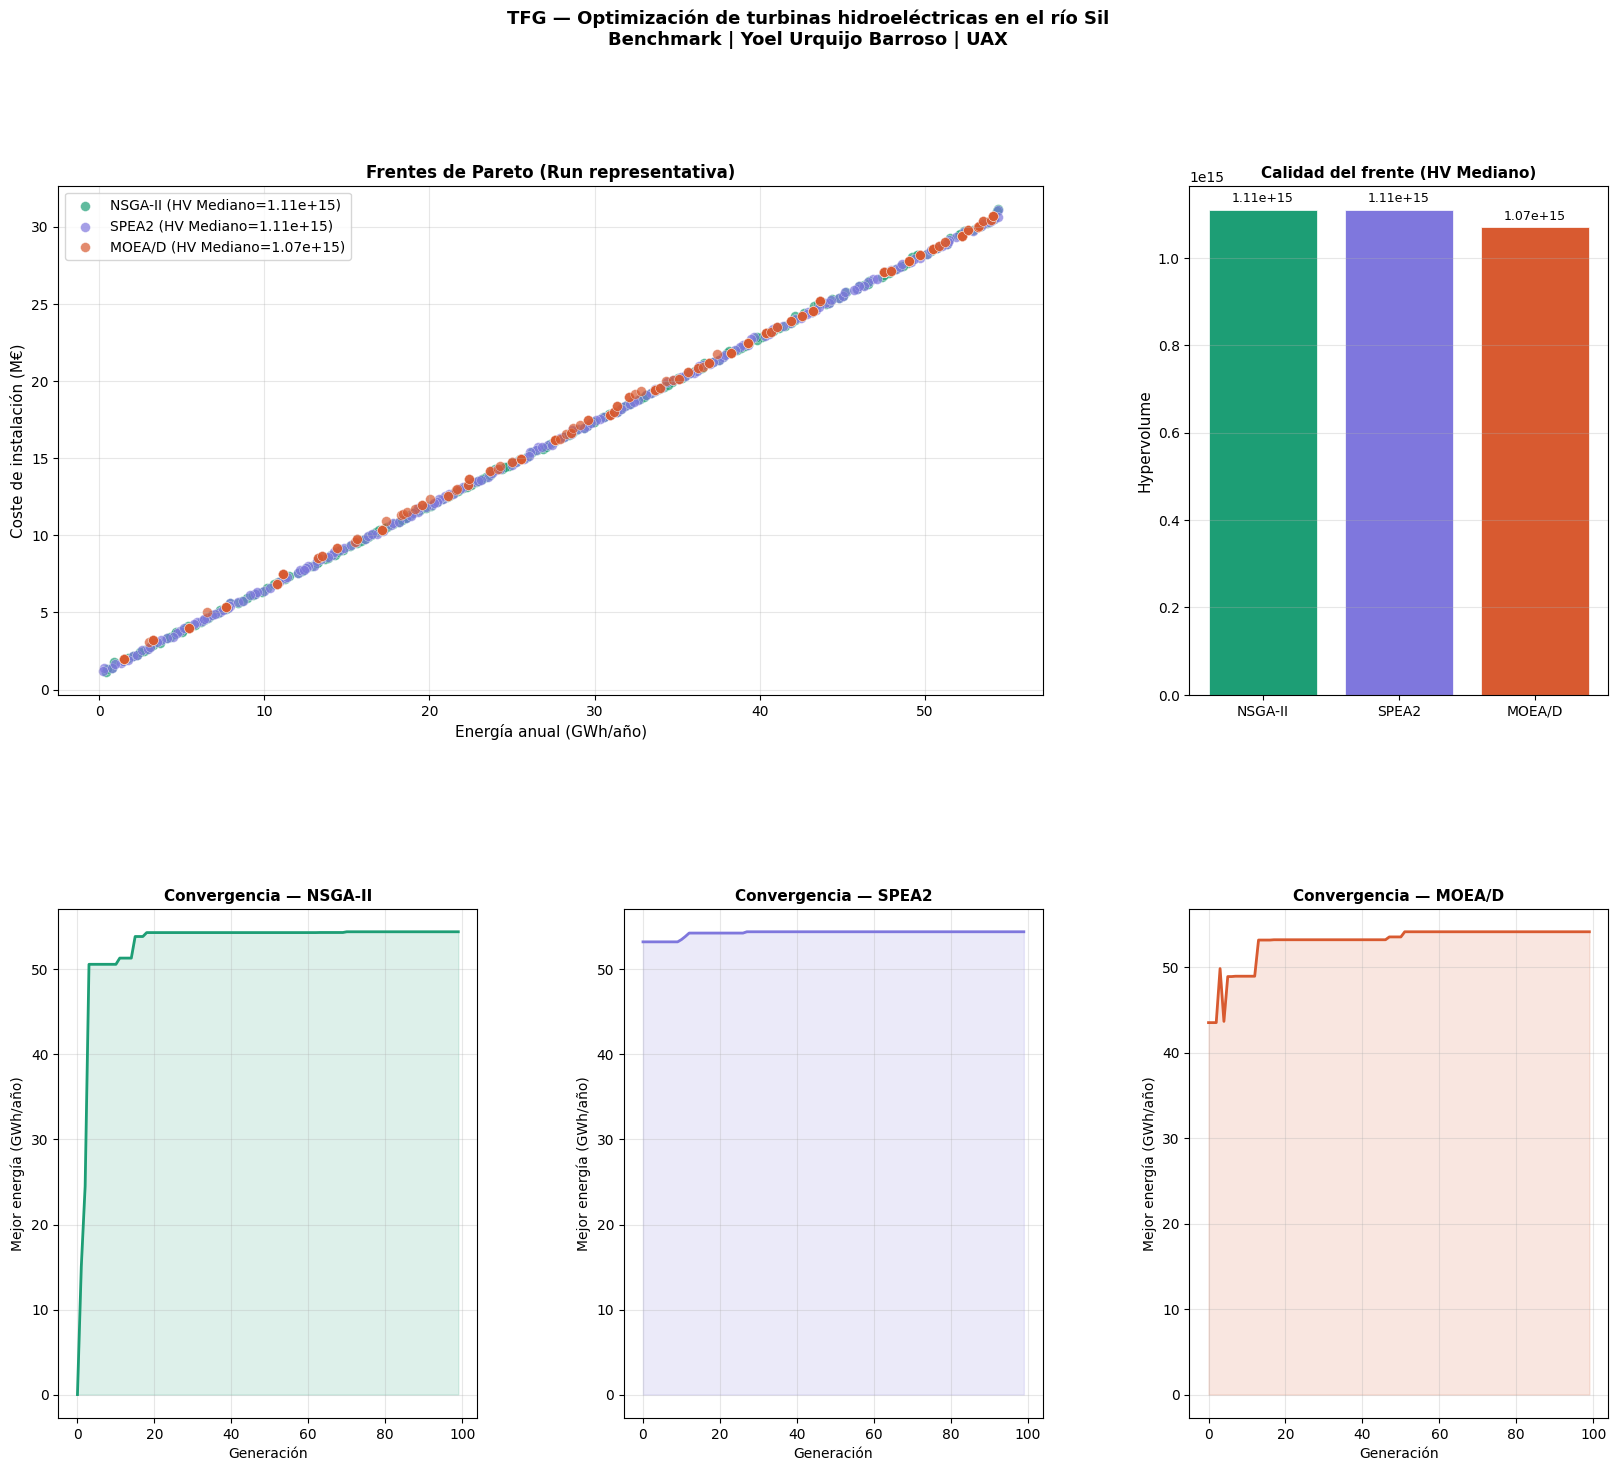

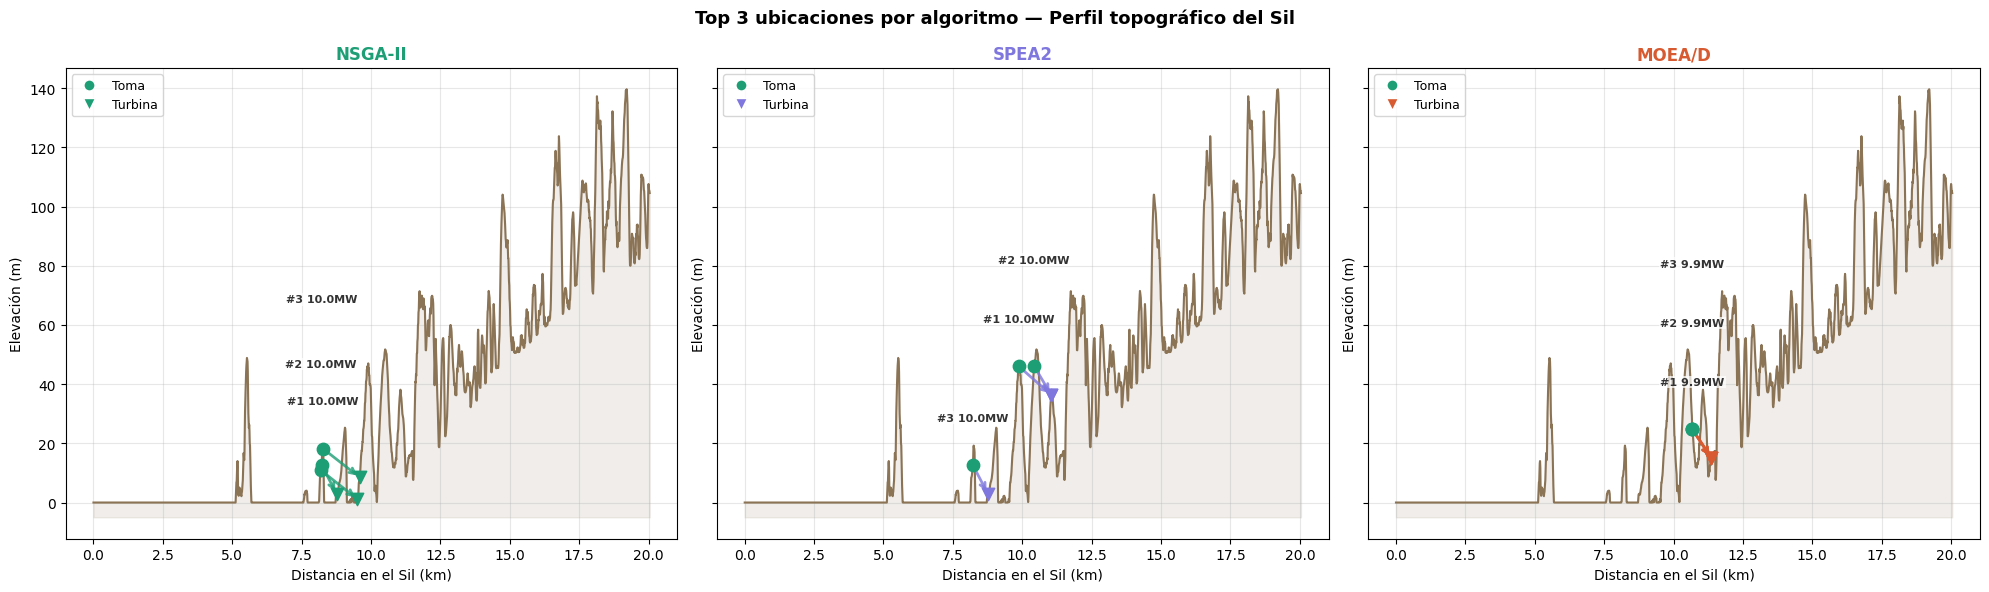

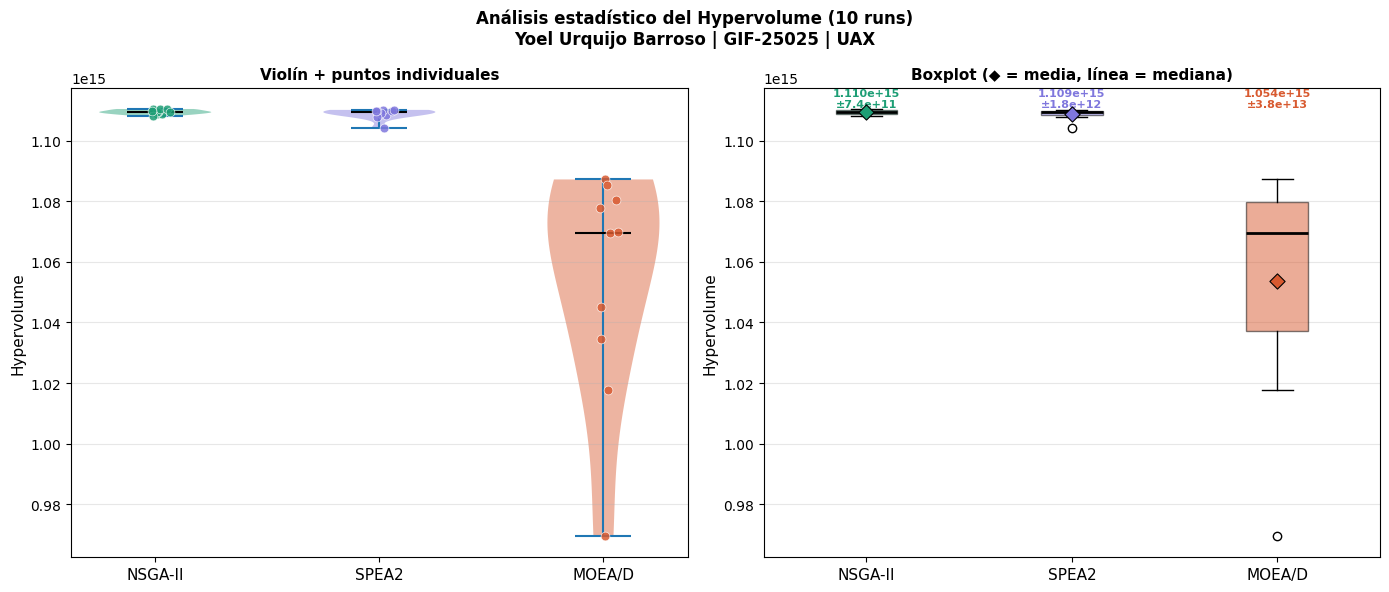


Ejecutando analisis de sensibilidad (Modelo: NSGA-II)
Base (Actual)             | Energía:   54.0 GWh | Coste:  30.9 M€
Eta Bajo (-10%)           | Energía:   54.4 GWh | Coste:  30.7 M€
Eta Alto (+10%)           | Energía:   54.3 GWh | Coste:  31.4 M€
Turbina Cara (+25%)       | Energía:   54.3 GWh | Coste:  33.3 M€
Obra Civil Barata (-50%)  | Energía:   54.4 GWh | Coste:  30.8 M€
Conexión ×2               | Energía:   54.0 GWh | Coste:  31.5 M€


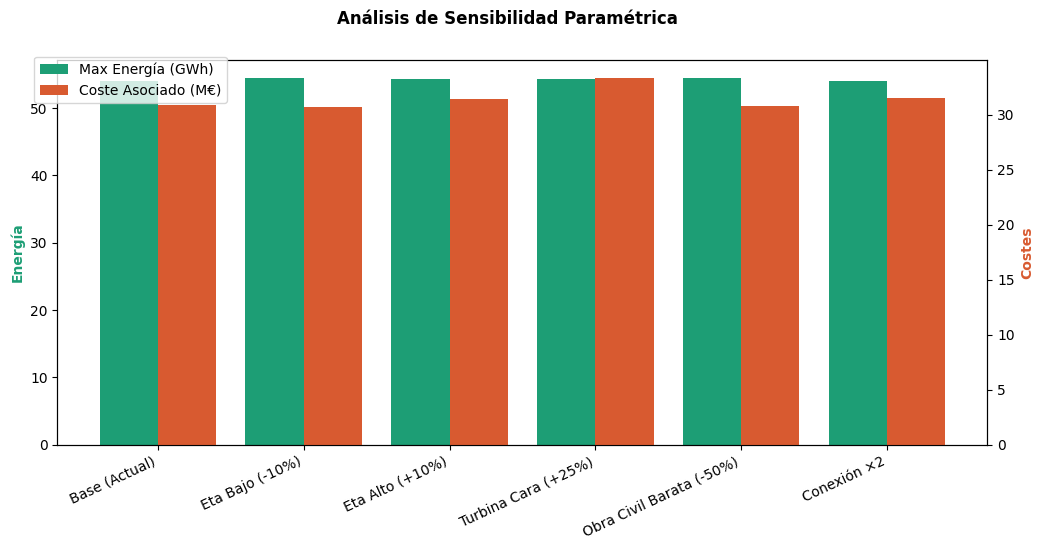


Proceso completado perfecto

Top 10 soluciones de cada algoritmo
Algoritmo  Potencia_MW  Energía_GWh  CAPEX_M€  Payback_Años  Toma (m)  Turbina (m)
    SPEA2        10.00        54.43     14.16           3.9      9870        11040
  NSGA-II        10.00        54.43     14.23           3.9      8270         9590
    SPEA2         9.99        54.41     13.68           3.7     10430        11040
  NSGA-II         9.98        54.34     14.11           3.8      8200         9510
    SPEA2         9.95        54.19     13.62           3.7      8220         8760
  NSGA-II         9.95        54.19     13.62           3.7      8220         8760
   MOEA/D         9.94        54.12     13.84           3.8     10680        11360
   MOEA/D         9.94        54.12     13.84           3.8     10680        11360
   MOEA/D         9.94        54.12     13.84           3.8     10680        11360
   MOEA/D         9.94        54.12     13.84           3.8     10680        11360


In [9]:
# Ejecucion principal del programa
print("Iniciando ejecución completa...")

# Multi-run benchmark
resultados_multi, resultados_mejor, ref_point, tiempos = ejecutar_benchmark_multi(n_pop=200, n_gen=100, n_runs=10, p=PARAMS)

# Métricas y Wilcoxon + Holm-Bonferroni
metricas, hv_runs, sp_runs = calcular_metricas_extendidas(resultados_multi, ref_point, tiempos)

# Guardado CSV — RUTA_OUT definida antes del bucle
RUTA_OUT = '/content/drive/MyDrive/TFG - UAX/CSV/'
dfs = []
for nombre, res in resultados_mejor.items():
    df_p = frente_a_dataframe(res, nombre, p=PARAMS)
    n_antes = len(df_p)
    df_p = df_p[df_p.apply(validar_solucion, axis=1)].reset_index(drop=True)
    n_filtradas = n_antes - len(df_p)
    if n_filtradas > 0:
        print(f"{nombre}:{n_filtradas} soluciones filtradas por límite legal 10 MW")
    print(f"{nombre}:{len(df_p)} soluciones válidas (≤10 MW, RD 413/2014)")
    dfs.append(df_p)
    df_p.to_csv(f'{RUTA_OUT}TFG_Pareto_{nombre.replace("/", "_")}.csv', index=False)

pd.concat(dfs).to_csv(f'{RUTA_OUT}TFG_Pareto_Todos.csv', index=False)

# Gráficas
graficar_benchmark(resultados_mejor, metricas)
graficar_mapa_top(resultados_mejor)
graficar_estadisticas(hv_runs, metricas)

# Análisis de Sensibilidad
ejecutar_analisis_sensibilidad()
print("\nProceso completado perfecto")
# Resumen ejecutivo
print("\n" + "="*60)
print("Top 10 soluciones de cada algoritmo")
print("="*60)

# Concatenar todos los frentes, ordenar por energía y coger las 10 mejores
df_top = pd.concat(dfs).sort_values('energia_kwh', ascending=False).head(10).copy()

# Formatear para lectura humana
df_top['Energía_GWh'] = (df_top['energia_kwh'] / 1e6).round(2)
df_top['Potencia_MW'] = (df_top['potencia_kw'] / 1000).round(2)
df_top['CAPEX_M€']    = (df_top['capex_inversion_eur'] / 1e6).round(2)
df_top['Payback_Años'] = df_top['payback_anios'].round(1)
df_top['Toma (m)']    = df_top['distancia_toma_m'].astype(int)
df_top['Turbina (m)'] = df_top['distancia_turb_m'].astype(int)

# Imprimir la tabla limpia
columnas_mostrar = ['Algoritmo', 'Potencia_MW', 'Energía_GWh', 'CAPEX_M€', 'Payback_Años', 'Toma (m)', 'Turbina (m)']
print(df_top[columnas_mostrar].to_string(index=False))